In [2]:
import numpy as np
from CalculoIndicesVecino import indices_primeros_vecinos as ipv, indices_segundos_vecinos as isv
import matplotlib.pyplot as plt

In [3]:
ipv(0, 0, 3, False)

[(None, None), (0, 1), (1, 0), (None, None)]

In [117]:
#np.random.seed(2*np.random.randint(0, 1_000_000)+1) #Semilla aleatoria
np.random.seed(0)
L = 5 #Tamaño de la red
S = np.random.choice([-1, 1], size=(L, L))
S

array([[-1,  1,  1, -1,  1],
       [ 1,  1,  1,  1,  1],
       [ 1, -1, -1,  1, -1],
       [-1, -1, -1, -1,  1],
       [-1,  1,  1, -1, -1]])

In [137]:
def flip_spin(J1, J2, T, S, E, M, is_periodica=False):
    beta = 1/T # unidades naturales, K_b=1
    L = len(S[0])
    
    for ix in range(0,L):
        for iy in range(0, L):
            ss = S[ix,iy] # Spin posicion (i, j)
            inn=ipv(ix, iy, L, is_periodica) # Primeros vecinos de la posicion (i,j)
            innn=isv(ix, iy, L, is_periodica) # Segundos vecinos de la posicion (i,j)
            nn = sum(S[i,j] for (i, j) in inn if (i is not None or j is not None)) # Sigma_i para primeros vecinos
            nnn = sum(S[i,j] for (i, j) in innn if (i is not None or j is not None)) # Sigma_i para segundos vecinos
            H = (-J1 * ss * nn) + (-J2 * ss * nnn) # Hamiltoniano original
            ss_new = -ss # se "simula" el flip del spin en la posicion i,j
            H_new = (-J1 * ss_new * nn) + (-J2 * ss_new * nnn) # Nuevo Hamiltoniano despues de hacer el flip del spin
            delta_E = H_new - H # Diferencia de energia antes de hacer el flip y despues de hacer el flip
            #delta_E = 2 * ss * (J1 * nn + J2 * nnn) #¿Equivalente para delta_E?
            W = np.exp(-delta_E * beta) #Factor para aplicar el algoritmo de Metropolis
            if(delta_E <= 0): # si el delta es menor se acepta el flip del spin
                S[ix, iy] = ss_new # se acepta (guarda) el flip en la posicion i,j
                M = M + (ss_new - ss) # Se actualiza el valor de la magnetizacion
                E = E + delta_E # Se actualiza el valor de la energia
                
            elif(delta_E > 0): # si el delta es mayor se aplica Metropolis
                r = np.random.uniform(0,1) #Se genera un numero aleatorio entre 0 y 1
                if(W>=r): # Si el factor es mayor que el numero aleatorio se acepta el flip del spin
                    S[ix, iy] = ss_new # se acepta (guarda) el flip en la posicion i,j
                    M = M + (ss_new - ss) # Se actualiza el valor de la magnetizacion
                    E = E + delta_E # Se actualiza el valor de la energia
                elif(W<r): # Si el factor es menor se rechaza el flip del spin
                    S[ix, iy] = ss # se deja el valor del spin que se tiene desde el comienzo
                    
    return E, M, S     

In [130]:
def energia_total_inicial(S, J1, J2, is_periodica=False):
    L = len(S[0])
    E = 0
    for i in range(L):
        for j in range(L):
            vecinos_nn = ipv(i, j, L, is_periodica)
            vecinos_nnn = isv(i, j, L, is_periodica)

            derecha = vecinos_nn[1]
            abajo = vecinos_nn[2]
            abajo_derecha = vecinos_nnn[1]
            abajo_izquierda = vecinos_nnn[2]

            if derecha[0] is not None:
                E += -J1 * S[i, j] * S[derecha]
            if abajo[0] is not None:
                E += -J1 * S[i, j] * S[abajo]
            if abajo_derecha[0] is not None:
                E += -J2 * S[i, j] * S[abajo_derecha]
            if abajo_izquierda[0] is not None:
                E += -J2 * S[i, j] * S[abajo_izquierda]

    return E

In [131]:
def calcular_Ms(S):
    L = len(S[0])
    N = L * L
    filas = np.arange(L).reshape(-1, 1)      
    mascara = np.where(filas % 2 == 0, 1, -1)

    Ms = np.abs(np.sum(mascara * S)) / (2 * N)
    return Ms

In [138]:
mcs_max = 10000
mcs_steps=range(0, mcs_max)
J1 = 1
J2 = -0.6*J1
T = 1

E0 = energia_total_inicial(S, J1, J2, is_periodica=False)
M0 = S.sum()

suma_E, suma_E2 = 0.0, 0.0
suma_M, suma_M2 = 0.0, 0.0
suma_Ms, suma_Ms2, suma_Ms4 = 0.0, 0.0, 0.0

historial_E = [E0]
historial_M = [M0]
historial_Ms = []

E_prom, E2_prom = [], []
M_prom, M2_prom = [], []
Ms_prom, Ms2_prom, Ms4_prom = [], [], [] 

E, M = E0, M0

for mcs in mcs_steps:
    E, M, S = flip_spin(J1, J2, T, S, E, M)
    Ms = calcular_Ms(S)
    
    historial_E.append(E)
    historial_M.append(M)
    historial_Ms.append(Ms)

    suma_E += E
    suma_E2 += E**2
    suma_M += M
    suma_M2 += M**2
    suma_Ms  += Ms
    suma_Ms2 += Ms**2
    suma_Ms4 += Ms**4
    n = mcs + 1

    E_prom.append( np.abs(suma_E) / n)
    E2_prom.append(suma_E2 / n)
    M_prom.append( np.abs(suma_M) / n)
    M2_prom.append(suma_M2 / n)
    Ms_prom.append(suma_Ms / n)
    Ms2_prom.append(suma_Ms2 / n)
    Ms4_prom.append(suma_Ms4 / n)


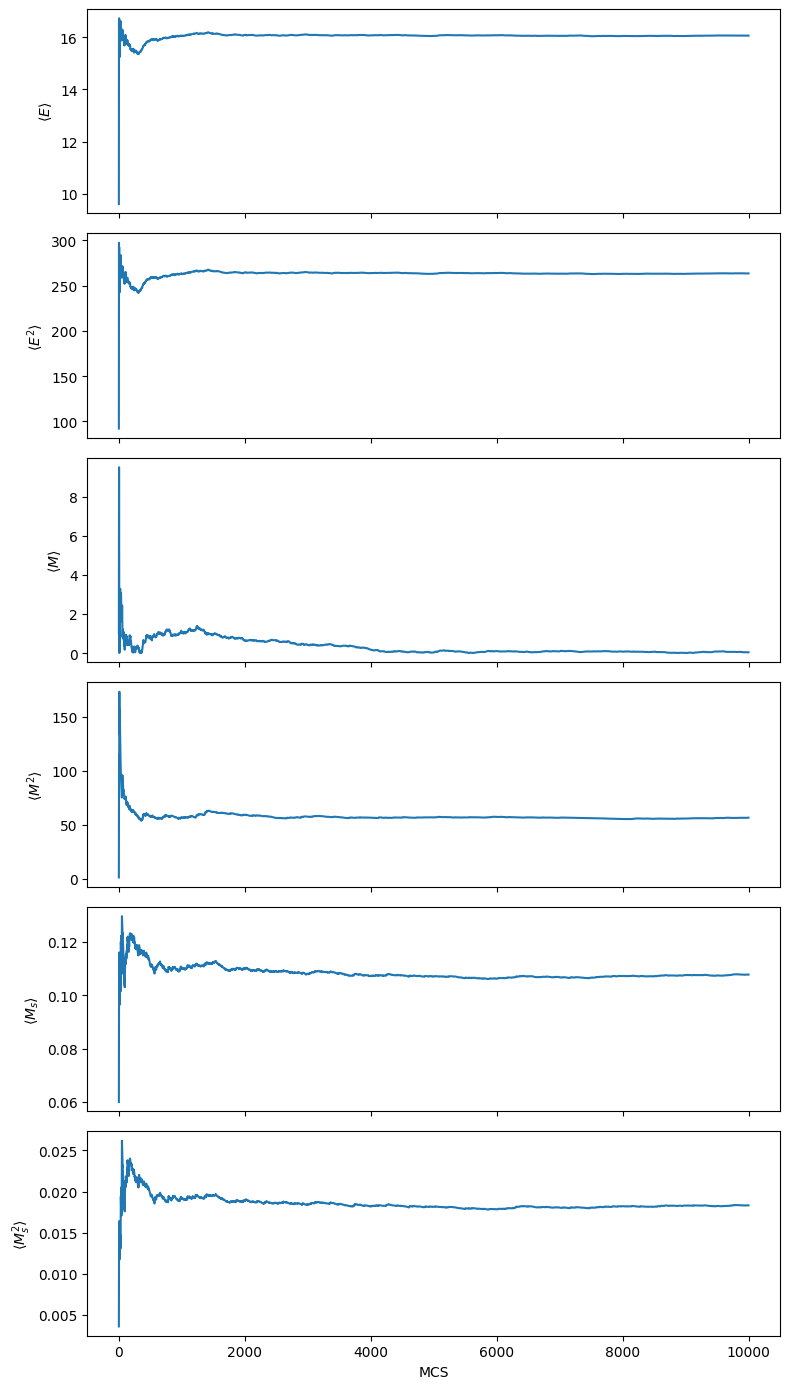

In [139]:
fig, axs = plt.subplots(6, 1, sharex=True, figsize=(8, 14))

axs[0].plot(mcs_steps, E_prom)
axs[0].set_ylabel(r"$\langle E \rangle$")

axs[1].plot(mcs_steps, E2_prom)
axs[1].set_ylabel(r"$\langle E^2 \rangle$")

axs[2].plot(mcs_steps, M_prom)
axs[2].set_ylabel(r"$\langle M \rangle$")

axs[3].plot(mcs_steps, M2_prom)
axs[3].set_ylabel(r"$\langle M^2 \rangle$")

axs[4].plot(mcs_steps, Ms_prom)
axs[4].set_ylabel(r"$\langle M_s \rangle$")

axs[5].plot(mcs_steps, Ms2_prom)
axs[5].set_ylabel(r"$\langle M_s^2 \rangle$")
axs[5].set_xlabel("MCS")

plt.tight_layout()
plt.show()

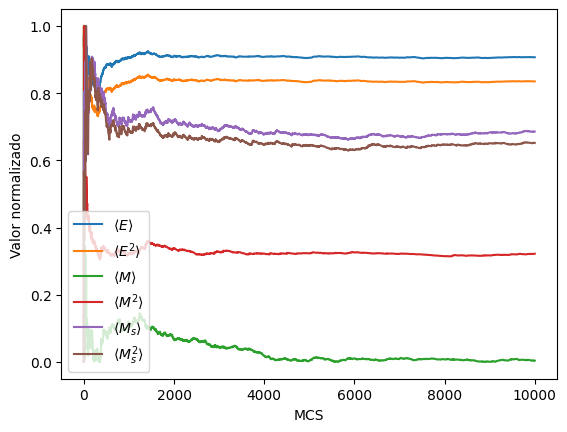

In [140]:
def normalizar(x):
    x = np.array(x, dtype=float)
    return (x - x.min()) / (x.max() - x.min())

plt.plot(mcs_steps, normalizar(E_prom), label=r"$\langle E \rangle$")
plt.plot(mcs_steps, normalizar(E2_prom), label=r"$\langle E^2 \rangle$")
plt.plot(mcs_steps, normalizar(M_prom), label=r"$\langle M \rangle$")
plt.plot(mcs_steps, normalizar(M2_prom), label=r"$\langle M^2 \rangle$")
plt.plot(mcs_steps, normalizar(Ms_prom), label=r"$\langle M_s \rangle$")
plt.plot(mcs_steps, normalizar(Ms2_prom), label=r"$\langle M_s^2 \rangle$")
plt.xlabel("MCS")
plt.ylabel("Valor normalizado")
plt.legend()
plt.show()

In [159]:
tao = 2000
E_termalizada = historial_E[tao+1:] #Se suma uno porque el arreglo del historial se inicializa con un valor
E_termalizada_prom = np.sum(E_termalizada) / len(E_termalizada)
E_termalizada_prom

np.float64(-16.06130000000003)

In [160]:
E2_termalizada_prom = np.sum(np.pow(E_termalizada,2)) / len(E_termalizada)
E2_termalizada_prom

np.float64(263.238400000001)

In [161]:
N = L * L
Cv = (E2_termalizada_prom - E_termalizada_prom**2) / (N * T**2)
Cv

np.float64(0.21092169239999975)

In [162]:
Ms_termalizado = historial_Ms[tao:]
Ms_termalizado_prom = np.sum(np.abs(Ms_termalizado)) / len(Ms_termalizado)
Ms_termalizado_prom

np.float64(0.10720000000000002)

In [163]:
Ms2_termalizado_prom = np.sum(np.pow(Ms_termalizado,2)) / len(Ms_termalizado)
Ms2_termalizado_prom 

np.float64(0.018193600000000004)

In [164]:
chi_s = (N / T) * (Ms2_termalizado_prom - Ms_termalizado_prom**2)
chi_s

np.float64(0.16754400000000003)

In [165]:
Ms4_termalizado_prom = np.sum(np.pow(Ms_termalizado, 4)) / len(Ms_termalizado)
Ms4_termalizado_prom 

np.float64(0.0010460569600000001)

In [166]:
U = 1 - Ms4_termalizado_prom / (3 * Ms2_termalizado_prom**2)
U

np.float64(-0.05340844166252001)